# Risk assessment

- A workflow from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [MULTI_infrastructure](https://github.com/CLIMAAX/MULTI_infrastructure) GitHub repository.
- See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html) page for information on how to run this notebook.

In this notebook, the calculation of risk associated with the variable under examination will be shown. Pandas dataframes will be presented which, in the example, show nine airports - the operator will need to modify the list of airports by adding/modifying names.
The same concept applies to exposure and vulnerability indicators - indicators will be presented that can be expanded or modified by the user.
The only mandatory thing is that the framework was conceptualized for at least two airports 

## Preparation work

### Import libraries

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.spatial
import xarray as xr

### Area of interest

In [2]:
region_name = 'IT'

### Path configuration

In [3]:
# Path to the folder containing the NetCDF files
indicators_path = f'../data_{region_name}/indicators/uerra'

# Folder to save the csv file where average exposure and vulnerability are going to be stored
csv_folder_path = f'../data_{region_name}/indicators/vulnerability_exposure'
os.makedirs(csv_folder_path, exist_ok=True)

## Define the airports

In [4]:
airports = [
    'Milano Malpensa', 'Milano Linate', 'Bergamo Orio al Serio',
    'Roma Fiumicino', 'Roma Ciampino', 'Napoli Capodichino',
    'Palermo Punta Raisi', 'Catania Fontanarossa', 'Cagliari Elmas'
]

In [5]:
def to_dataframe(dct):
    idx = pd.Index(airports, name="airport")
    return pd.DataFrame(dct, index=idx, dtype=float)

In [6]:
coords = to_dataframe({
    "latitude": [45.63, 45.45, 45.67, 41.80, 41.80, 40.88, 38.18, 37.47, 39.25],
    "longitude": [8.73, 9.28, 9.71, 12.25, 12.59, 14.29, 13.10, 15.07, 9.06]
})
coords

,latitude,longitude
airport,,
Milano Malpensa,45.63,8.73
Milano Linate,45.45,9.28
Bergamo Orio al Serio,45.67,9.71
Roma Fiumicino,41.80,12.25
Roma Ciampino,41.80,12.59
Napoli Capodichino,40.88,14.29
Palermo Punta Raisi,38.18,13.10
Catania Fontanarossa,37.47,15.07
Cagliari Elmas,39.25,9.06


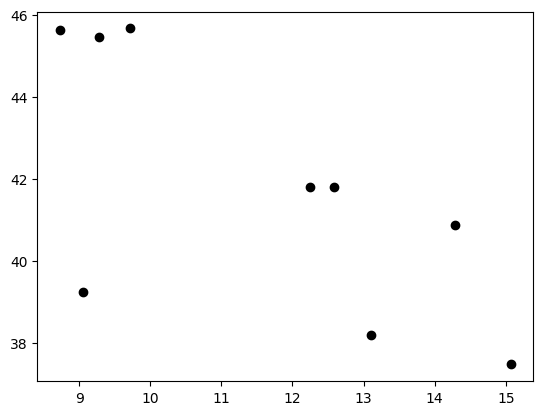

In [7]:
plt.scatter(coords.longitude, coords.latitude, color="k")

## Normalize components

The aim of normalization processes is to transform the values of these indicators, which are measured at different scales and in different units, into comparable values considered on a common scale ([Master Adapt, 2018](https://masteradapt.eu/wordpress/wp-content/uploads/2018/03/MA-linee-guida-A1-1.pdf)).
We used the Min-Max method to transform all values to scores in a range from 0 to 1, where the value 0 represents the optimal level, while the value 1 reflects the most critical estimates:

In [8]:
def normalize_columns(df):
    return (df - df.min()) / (df.max() - df.min())

## Hazard

In [9]:
def load_all(files):
    das = []
    for name, file in files.items():
        path = os.path.join(indicators_path, file)
        if name == "*":
            ds = xr.open_dataset(path)
            das.extend(ds.data_vars.values())
        else:
            da = xr.open_dataarray(path)
            das.append(da.rename(name))
    return xr.merge(das, compat="override")


def extract_points(ds, points):
    grid = np.column_stack([
        ds["latitude"].values.flatten(),
        ds["longitude"].values.flatten()
    ])
    tree = scipy.spatial.cKDTree(grid)
    _, closest_idx = tree.query(coords.values, k=1)
    idx_y, idx_x = np.unravel_index(closest_idx, ds["latitude"].shape)
    return (
        ds
        .isel(
            x=xr.DataArray(idx_x, dims="airport"),
            y=xr.DataArray(idx_y, dims="airport")
        )
        .drop_vars(["latitude", "longitude"])
        .assign_coords({"airport": coords.index})
        .to_dataframe()
    )

In [10]:
data_temp = load_all({
    "Days Above 35°C": "Temp_DaysAbove35.nc",
    "Days Above 40°C": "Temp_DaysAbove40.nc",
    "Days Above 45°C": "Temp_DaysAbove45.nc",
})

In [11]:
indicators_temp = extract_points(data_temp, coords)
indicators_temp

,Days Above 35°C,Days Above 40°C,Days Above 45°C
airport,,,
Milano Malpensa,0.000000,0.000000,0.0
Milano Linate,0.533333,0.000000,0.0
Bergamo Orio al Serio,0.433333,0.000000,0.0
Roma Fiumicino,0.166667,0.000000,0.0
Roma Ciampino,3.400000,0.000000,0.0
Napoli Capodichino,3.433333,0.000000,0.0
Palermo Punta Raisi,1.266667,0.100000,0.0
Catania Fontanarossa,8.933333,1.133333,0.2
Cagliari Elmas,6.700000,0.266667,0.0


<Axes: title={'center': 'Hazard: Temperature'}, ylabel='airport'>

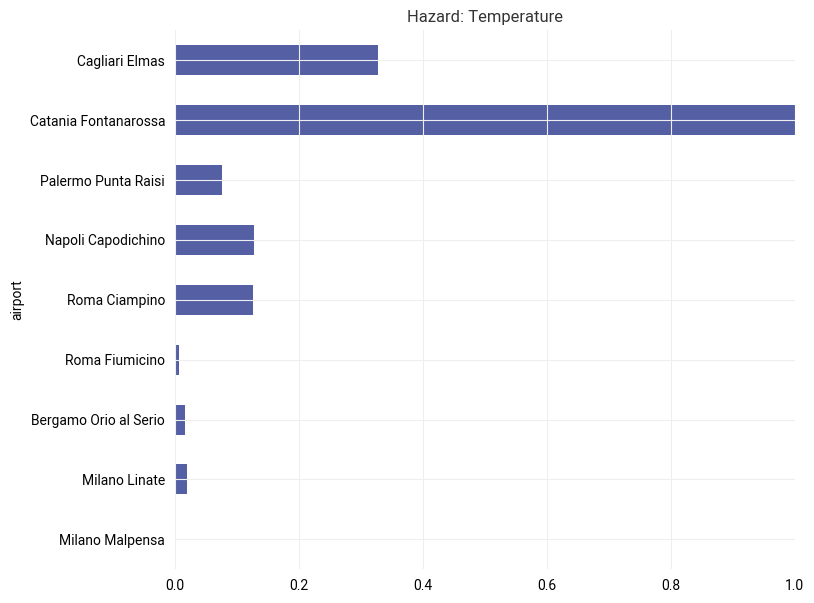

In [31]:
hazard_temp = normalize_columns(indicators_temp).mean(axis=1, skipna=True)
hazard_temp.plot.barh(title="Hazard: Temperature", xlim=(0, 1))

In [15]:
data_precip = load_all({
    "*": "Precip_return_levels_gumbel.nc",
    "Precip_P99": "Precip_P99.nc",
    "Precip_P999": "Precip_P999.nc"
})
# Remove some left-over coordinates so they don't show up in the indicators table
data_precip = data_precip.drop_vars(["x", "y", "time", "quantile"], errors="ignore")

indicators_precip = extract_points(data_precip, coords)
indicators_precip

,return_period_2_y,return_period_5_y,return_period_10_y,return_period_20_y,return_period_30_y,return_period_50_y,return_period_100_y,return_period_150_y,return_period_200_y,return_period_500_y,Precip_P99,Precip_P999
airport,,,,,,,,,,,,
Milano Malpensa,77.240410,97.857880,111.508438,124.602386,132.135010,141.551163,154.251877,161.657974,166.906250,183.601303,48.059845,94.042389
Milano Linate,56.678417,70.069450,78.935478,87.439987,92.332420,98.448204,106.697311,111.507561,114.916313,125.759735,34.706484,63.180023
Bergamo Orio al Serio,49.203640,59.805862,66.825455,73.558823,77.432358,82.274467,88.805618,92.614090,95.312943,103.898109,33.550508,51.886977
Roma Fiumicino,50.875408,69.739494,82.229156,94.209549,101.101570,109.716927,121.337532,128.113785,132.915726,148.190964,27.939688,60.487923
Roma Ciampino,43.058388,56.674309,65.689232,74.336563,79.311157,85.529648,93.917290,98.808327,102.274323,113.299850,26.153749,52.537727
Napoli Capodichino,60.708721,85.161652,101.351616,116.881424,125.815338,136.983170,152.046585,160.830429,167.055054,186.855865,35.195312,84.431564
Palermo Punta Raisi,56.251366,81.191704,97.704376,113.543732,122.655724,134.046158,149.409836,158.368759,164.717453,184.912949,35.360001,88.106552
Catania Fontanarossa,58.424789,85.944069,104.164230,121.641449,131.695663,144.263901,161.216263,171.101578,178.106750,200.390549,26.499609,81.429756
Cagliari Elmas,32.551186,44.475163,52.369877,59.942673,64.299118,69.744881,77.090256,81.373528,84.408836,94.064301,17.672501,37.748158


<Axes: title={'center': 'Hazard: Precipitation'}, ylabel='airport'>

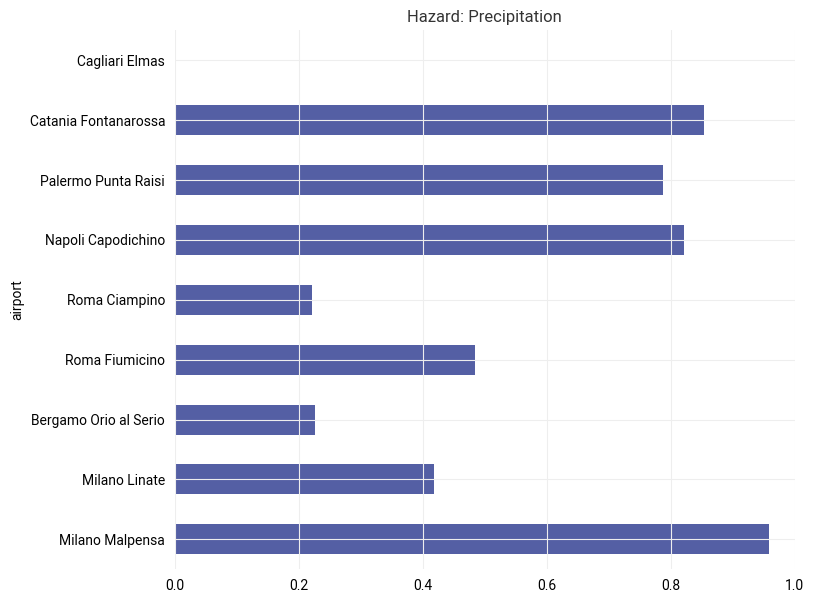

In [16]:
hazard_precip = normalize_columns(indicators_precip).mean(axis=1, skipna=True)
hazard_precip.plot.barh(title="Hazard: Precipitation", xlim=(0, 1))

## Exposure

### Air and land side components

The various airports components, divided into landside and airside areas, were considered as exposed samples in accordance with [De Vivo et al. (2022)](https://doi.org/10.1007/s11069-021-05066-0).

The **air side components** include the structures used for the movement of aircraft, such as runways, taxiways, tower, and aprons:

| Air side  | Unit of measurement |
|-----------|---------------------|
| Runways   | Area [m²]           | 
| Taxiways  | Area [m²]           | 
| Tower     | Height [m]          | 
| Apron     | Area [m²]           | 


The **land side components** refer to the public access areas such as offices, terminals, airports access systems and parking areas:

| Land side                    | Unit of measurement |
|------------------------------|---------------------|
| Terminal                     | Area [m²]           | 
| Offices and other buildings  | Area [m²]           | 
| Airport accesses systems     | Area [m²]           | 
| Carparks                     | Number              | 

Define the values for each indicator and airport: (insert `None` where data is not available)

In [17]:
air_land_side_components = to_dataframe({
    'Runways': [470400, 159742, 145530, 396000, 9900, 118260, 292650, 109575, 126000],
    'Taxiways': [250.5, 156, 183, 300, 301, 99, 368, 159, 604],
    'Tower': [80, 47, 30, 56, 60, 40, 25, 12, 28],
    'Apron': [1319000, 387000, 190000, 797250, None, 200000, 148000, 180000, 156000],
    'Terminals': [315000, 85050, 53025, 354300, 20950, 30700, 35400, 43310, 41290],
    'Offices_and_other_buildings': [26715, 13527, 7075, 29520, 5950, 1915, 4180, 6920, 5030],
    'Airport_accesses_systems': [31660, None, None, None, None, None, None, None, None],
    'Carparks': [15000, 3000, 8000, 20100, 1220, 1500, 1364, 1800, 2133]
})
air_land_side_components

,Runways,Taxiways,Tower,Apron,Terminals,Offices_and_other_buildings,Airport_accesses_systems,Carparks
airport,,,,,,,,
Milano Malpensa,470400.0,250.5,80.0,1319000.0,315000.0,26715.0,31660.0,15000.0
Milano Linate,159742.0,156.0,47.0,387000.0,85050.0,13527.0,NaN,3000.0
Bergamo Orio al Serio,145530.0,183.0,30.0,190000.0,53025.0,7075.0,NaN,8000.0
Roma Fiumicino,396000.0,300.0,56.0,797250.0,354300.0,29520.0,NaN,20100.0
Roma Ciampino,9900.0,301.0,60.0,NaN,20950.0,5950.0,NaN,1220.0
Napoli Capodichino,118260.0,99.0,40.0,200000.0,30700.0,1915.0,NaN,1500.0
Palermo Punta Raisi,292650.0,368.0,25.0,148000.0,35400.0,4180.0,NaN,1364.0
Catania Fontanarossa,109575.0,159.0,12.0,180000.0,43310.0,6920.0,NaN,1800.0
Cagliari Elmas,126000.0,604.0,28.0,156000.0,41290.0,5030.0,NaN,2133.0


In [18]:
air_land_side_normalized = normalize_columns(air_land_side_components)
air_land_side_normalized

,Runways,Taxiways,Tower,Apron,Terminals,Offices_and_other_buildings,Airport_accesses_systems,Carparks
airport,,,,,,,,
Milano Malpensa,1.000000,0.300000,1.000000,1.000000,0.882106,0.898388,NaN,0.729873
Milano Linate,0.325390,0.112871,0.514706,0.204099,0.192290,0.420648,NaN,0.094280
Bergamo Orio al Serio,0.294528,0.166337,0.264706,0.035867,0.096220,0.186923,NaN,0.359110
Roma Fiumicino,0.838436,0.398020,0.647059,0.554441,1.000000,1.000000,NaN,1.000000
Roma Ciampino,0.000000,0.400000,0.705882,NaN,0.000000,0.146169,NaN,0.000000
Napoli Capodichino,0.235309,0.000000,0.411765,0.044406,0.029249,0.000000,NaN,0.014831
Palermo Punta Raisi,0.614007,0.532673,0.191176,0.000000,0.043348,0.082050,NaN,0.007627
Catania Fontanarossa,0.216450,0.118812,0.000000,0.027327,0.067077,0.181308,NaN,0.030720
Cagliari Elmas,0.252117,1.000000,0.235294,0.006832,0.061017,0.112842,NaN,0.048358


In [19]:
exposure = air_land_side_normalized.mean(axis=1, skipna=True)

<Axes: title={'center': 'Exposure'}, ylabel='airport'>

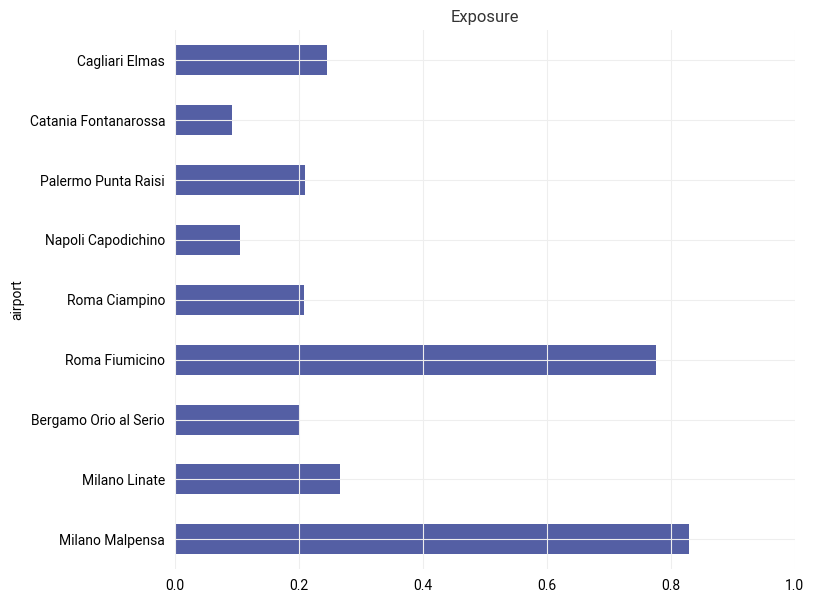

In [20]:
exposure.plot.barh(title="Exposure", xlim=(0, 1))

## Vulnerability

Vulnerability reflects “the propensity or predisposition of a system to be adversely affected. It encompasses a variety of concepts and elements including sensitivity or susceptibility to harm and lack of capacity to cope and adapt opportunities, or to respond to consequences” (IPCC, 2022).

Vulnerability is composed by sensitivity and adaptive capacity.

### Sensitivity

Sensitivity is intended as the degree to which the system is (positively or negatively) affected by climate variability or climate change. 

| Indicator                     |Unit of measurement                |
|-------------------------------|-----------------------------------|
| Soil Sealing                  | Area [%]                          | 
| Passenger                     | Number                            | 
| Building in bad condition     | Number or Absence/Presence        | 
| Age building                  | Age                               | 
| Air traffic                   | Number                            |
| Parking accesses              | Number                            |
| Staff work outside airport    | Number                            |

Define the sensitivity indicators and their values: (use `None` where data is not available)

In [21]:
sensitivity_indicators = to_dataframe({
    'Soil_sealing': [1235, 300, 300, 1590, 133, 217, 391, 225, 246],
    'Passengers': [27000000, 7000000, 13857257, 43532573, 5879496, 10860068, 7018087, 10223113, 4747806],
    'Buildings_bad_conditions_or_maintenance': [None, None, None, None, None, None, None, None, None],
    'Age_buildings': [73, 82, 83, 63, 105, 111, 61, 97, 84],
    'Air_traffic': [201050, 85730, 95377, 309783, 52253, 82577, 54243, 73494, 39691],
    'Parking_accesses': [None, None, None, None, None, None, None, None, None],
    'Staff_work': [1997.1, 855.9, 1044, 2363.9, 1013.1, None, 283, 183, 146]
})

sensitivity_normalized = normalize_columns(sensitivity_indicators)
sensitivity_normalized

,Soil_sealing,Passengers,Buildings_bad_conditions_or_maintenance,Age_buildings,Air_traffic,Parking_accesses,Staff_work
airport,,,,,,,
Milano Malpensa,0.756349,0.573735,NaN,0.24,0.597422,NaN,0.834618
Milano Linate,0.114619,0.058069,NaN,0.42,0.170457,NaN,0.320078
Bergamo Orio al Serio,0.114619,0.234872,NaN,0.44,0.206174,NaN,0.404888
Roma Fiumicino,1.000000,1.000000,NaN,0.04,1.000000,NaN,1.000000
Roma Ciampino,0.000000,0.029179,NaN,0.88,0.046510,NaN,0.390955
Napoli Capodichino,0.057653,0.157594,NaN,1.00,0.158783,NaN,NaN
Palermo Punta Raisi,0.177076,0.058535,NaN,0.00,0.053878,NaN,0.061770
Catania Fontanarossa,0.063143,0.141172,NaN,0.72,0.125154,NaN,0.016682
Cagliari Elmas,0.077557,0.000000,NaN,0.46,0.000000,NaN,0.000000


### Adaptative capacity

Adaptive capacity is “the ability of systems, institutions, humans and other organisms to adjust to potential damage, to take advantage of ???TODO

Following the list of Adaptive capacity indicator considered in this work ...

This indicators are defined by the classes reported below and included in De Vivo et al. (2021).
If the indicator is present or absent, its value will be 0.9 or 0.1, respectively.

**Risk awareness: Initiatives for mitigation to climate change:**

1. Adherence to "NetZero2050" Programme (neutrality3+)
2. Certification ISO 50001 and initiatives of "energy saving"
3. Neutrality 3+ Airport carbon accreditation
4. Neutrality 4+ Airport carbon accreditation; EP-100 intelligent use of energy from "The Climate Group"- Certification ISO 50001
5. Level 2 Airport carbon accreditation, environmental improvement program
6. Commitment to obtaining certfiication

**Initiatives for adaptation to climate change:**

- **Efficient drainage system**
  1. Present

- **Insurance policy for extreme events**
  1. Absent

- **Monitoring and alarm system**
  1. Present
  2. Present (but alert wind shear)
  2. Absent
  
- **Bioinfiltration and permeable pavements**
  1. Present
  2. Absent

- **Risk awareness (and initiatives of mitigation)**
  1. Risk management framework 
  2. Development of local (Urban) climate change mitigation and adaptation strategies
  3. Sustainability Report 2019
  4. gesap environmental report
  5. Absent

- **Guidelines for adaptation plan to climate change**
  1. Plan (PACC) and regional strategy for adaptation to climate change
  2. Regional plan under development
  3. Absent
  4. Sustainable Energy and Climate Action Plan (Covenant of Mayors)
  5. Sustainable Energy and Climate Action Plan (Covenant of Mayors) municipality of Catania
  6. Regional climate change adaptation strategy



| Class No. | Description      | Value Range | Indicator Range (0-1) |
|-----------|------------------|-------------|-----------------------|
| 1         | Optimal          | 0 - 0.2     | 0.1                   |
| 2         | Quite Positive   | 0.2 - 0.4   | 0.3                   |
| 3         | Neutral          | 0.4 - 0.6   | 0.5                   |
| 4         | Quite Negative   | 0.6 - 0.8   | 0.7                   |
| 5         | Critical         | 0.8 - 1     | 0.9                   |


Define the sensitivity indicators and their values: (use `None` where data is not available)

In [22]:
adaptive_indicators = to_dataframe({
    'Vegetation_zone': [None, None, None, None, None, None, None, None, None],
    'Initiatives_for_optimization_of_energy ': [0.3, 0.3, 0.3, 0.1, 0.1, 0.3, 0.5, 0.7, 0.7],
    'Green_wall': [0.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Green_roof': [0.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Heat_resistent_coating': [0.9, 0.9, 0.9, 0.1, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Insurance_policy_for_extreme_events': [0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Guidelines_for_adaptation_climate_change': [0.3, 0.3, 0.3, 0.5, 0.5, 0.9, 0.3, 0.3, 0.3],
    'Evening_departures': [None, None, None, None, None, None, None, None, None]
})
adaptive_indicators

,Vegetation_zone,Initiatives_for_optimization_of_energy,Green_wall,Green_roof,Heat_resistent_coating,Insurance_policy_for_extreme_events,Guidelines_for_adaptation_climate_change,Evening_departures
airport,,,,,,,,
Milano Malpensa,NaN,0.3,0.1,0.1,0.9,0.9,0.3,NaN
Milano Linate,NaN,0.3,0.9,0.9,0.9,0.9,0.3,NaN
Bergamo Orio al Serio,NaN,0.3,0.9,0.9,0.9,0.9,0.3,NaN
Roma Fiumicino,NaN,0.1,0.9,0.9,0.1,0.9,0.5,NaN
Roma Ciampino,NaN,0.1,0.9,0.9,0.9,0.9,0.5,NaN
Napoli Capodichino,NaN,0.3,0.9,0.9,0.9,0.9,0.9,NaN
Palermo Punta Raisi,NaN,0.5,0.9,0.9,0.9,0.9,0.3,NaN
Catania Fontanarossa,NaN,0.7,0.9,0.9,0.9,0.9,0.3,NaN
Cagliari Elmas,NaN,0.7,0.9,0.9,0.9,0.9,0.3,NaN


### Vulnerability calculation

As mentioned before, the Vulnerability is the mean between the sensitivity and adaptive capacity

In [23]:
vulnerability = 0.5 * (
    sensitivity_normalized.mean(skipna=True, axis=1)
    + adaptive_indicators.mean(skipna=True, axis=1)
)

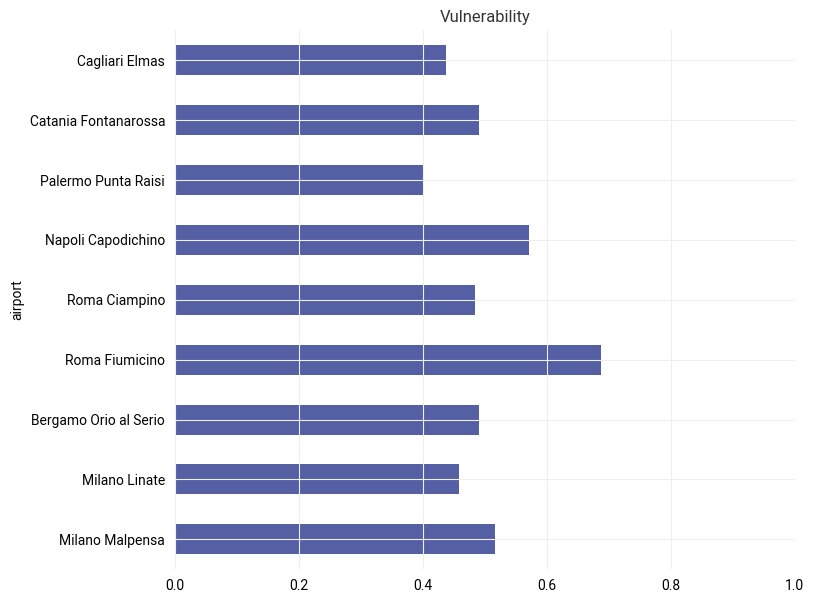

In [24]:
ax = vulnerability.plot.barh(title="Vulnerability", xlim=(0, 1))

## Risk calculation

The risk (`R`) will be computed by multiplication of the three components hazard (`H`), exposure (`E`) and vulnerability (`V`):

    R = H * E * V

### For UERRA Datasets

**Extreme Temperature**

In the cell below the nearest point to the airport was selected. In the framework the normalization of all the indicator was made, then a mean to obtain a single value

In [48]:
hazard_uerra_temp_path = '/work/cmcc/dg07124/climax/indicators/hazards_csv/hazard_uerra_temp.csv'
hazard_uerra_temp = pd.read_csv(hazard_uerra_temp_path, index_col='Airports')
# Standardize the airport names to Title Case
hazard_uerra_temp.index = hazard_uerra_temp.index.str.title()
hazard_uerra_temp['average'] = pd.to_numeric(hazard_uerra_temp['average'], errors='coerce')
hazard_uerra_temp = hazard_uerra_temp.sort_index()
hazard_uerra_temp

,average
Airports,
Bergamo Orio Al Serio,13.090606
Cagliari Elmas,15.807716
Catania Fontanarossa,17.416528
Milano Linate,13.321168
Milano Malpensa,12.487971
Napoli Capodichino,14.670617
Palermo Punta Raisi,13.622919
Roma Ciampino,14.587898
Roma Fiumicino,12.443477


In [49]:
avg_df_exposure.index = avg_df_exposure.index.str.title()
avg_df_exposure['average'] = pd.to_numeric(avg_df_exposure['average'], errors='coerce')
avg_df_exposure = avg_df_exposure.sort_index()
avg_df_exposure

,average
Bergamo Orio Al Serio,0.200527
Cagliari Elmas,0.245209
Catania Fontanarossa,0.091670
Milano Linate,0.266326
Milano Malpensa,0.830052
Napoli Capodichino,0.105080
Palermo Punta Raisi,0.210126
Roma Ciampino,0.208675
Roma Fiumicino,0.776851


In [50]:
vulnerability_df.index = vulnerability_df.index.str.title()
vulnerability_df['average'] = pd.to_numeric(vulnerability_df['average'], errors='coerce')
vulnerability_df = vulnerability_df.sort_index()
vulnerability_df

,average
Bergamo Orio Al Serio,0.490055
Cagliari Elmas,0.437089
Catania Fontanarossa,0.489948
Milano Linate,0.458322
Milano Malpensa,0.516879
Napoli Capodichino,0.571754
Palermo Punta Raisi,0.401793
Roma Ciampino,0.484664
Roma Fiumicino,0.687333


In [51]:
# Now multiply the 'average' column of each DataFrame
uerra_risk_temp = avg_df_exposure['average'] * hazard_uerra_temp['average'] * vulnerability_df['average']

# Convert the Series to a DataFrame
uerra_risk_temp_df = pd.DataFrame(uerra_risk_temp)

# Rename the column
uerra_risk_temp_df.columns = ['Uerra Risk Temperature']
uerra_risk_temp_df

,Uerra Risk Temperature
Bergamo Orio Al Serio,1.286406
Cagliari Elmas,1.694239
Catania Fontanarossa,0.782242
Milano Linate,1.626026
Milano Malpensa,5.357799
Napoli Capodichino,0.881409
Palermo Punta Raisi,1.150143
Roma Ciampino,1.475383
Roma Fiumicino,6.644263


### Risk classes

To evaluate the risk classes for each of the airport the Quantile Method was used. Classifying each airport in terms of quantile with respect to all other airport taken into account

In [52]:
# Function to calculate the quantile of the risk for all 9 airports
def classify_dataframe(df, column_name):
    """
    Classifies a given dataframe column into quantiles and assigns categorical classes.
    
    Parameters:
    df (pd.DataFrame): Input dataframe with numerical values.
    column_name (str): The column name to be classified.
    
    Returns:
    pd.DataFrame: Dataframe with quantile values and class categories.
    """
    df = df.copy()  # Ensure the original dataframe is not modified
    
    # Calculating the quantiles on a scale from 0 to 1
    df['Quantile'] = df[column_name].rank(pct=True)
    
    # Defining classification labels
    labels = ["Very Low", "Low", "Medium", "High", "Very High"]
    
    # Assigning classes based on quantile values
    df['Class'] = pd.qcut(df['Quantile'], q=5, labels=labels)
    return df

In [53]:
# Define a function to color the class column based on the classes
def highlight_class_column(s):
    colors = {
        "Very Low": "background-color: forestgreen",
        "Low": "background-color: limegreen",
        "Medium": "background-color: yellow",
        "High": "background-color: orange",
        "Very High": "background-color: red; color: white"
    }
    return [colors.get(val, "") if s.name == "Class" else "" for val in s]

In [54]:
# Call the function that calculates the quantile
classified_df = classify_dataframe(uerra_risk_temp_df, "Uerra Risk Temperature")

# Apply styling
styled_uerra_risk_temp_df = classified_df.style.apply(highlight_class_column, axis=0)

# Displaying the classified risk
display(styled_uerra_risk_temp_df)

,Uerra Risk Temperature,Quantile,Class
Bergamo Orio Al Serio,1.286406,0.444444,Low
Cagliari Elmas,1.694239,0.777778,High
Catania Fontanarossa,0.782242,0.111111,Very Low
Milano Linate,1.626026,0.666667,High
Milano Malpensa,5.357799,0.888889,Very High
Napoli Capodichino,0.881409,0.222222,Very Low
Palermo Punta Raisi,1.150143,0.333333,Low
Roma Ciampino,1.475383,0.555556,Medium
Roma Fiumicino,6.644263,1.000000,Very High
